In [ ]:
import os
import requests
import aiohttp
import asyncio
import nest_asyncio
import pandas as pd
import time
import scrapy
from scrapy_playwright.page import PageMethod
from bs4 import BeautifulSoup
import nest_asyncio
import glob
import numpy as np
import matplotlib.pyplot as plt
from fuzzywuzzy import fuzz, process
import re


c:\Users\teele\anaconda3\envs\adhoc_env\lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


### Le Peng Data

In [ ]:
adhoc_leads = (
    pd.read_excel(r"C:\Users\teele\Documents\GitHub\Adhoc_Leads_Refinement_Pipeline\10k_adhoc_leads\Merged_Raw_Data\Merge_Kalai_and_Ish\[Final] Merged_Multiple_Raw_Data_Files_NoDuplicates_Cleaned_Contact Number Reformatted_Deduplicated_Corrected(SG Number).xlsx")
    .rename(columns=lambda c: c.upper().strip().replace(' ', '_').replace('-', '_'))
)
adhoc_leads.shape

(6765, 39)

In [ ]:
adhoc_leads = (
    pd.read_excel(r"C:\Users\teele\Documents\GitHub\Adhoc_Leads_Refinement_Pipeline\10k_adhoc_leads\Merged_Raw_Data\Merge_Kalai_and_Ish\[Final] Merged_Multiple_Raw_Data_Files_NoDuplicates_Cleaned_Contact Number Reformatted_Deduplicated_Corrected(SG Number).xlsx")
    .rename(columns=lambda c: c.upper().strip().replace(' ', '_').replace('-', '_'))
)

# Keep rows where at least one contact number is not NaN
cols = [f'CONTACT_NUMBER_{i}' for i in range(1, 8)]
adhoc_leads = adhoc_leads[adhoc_leads[cols].notna().any(axis=1)]

print(adhoc_leads.shape)
adhoc_leads.head(5)


(6765, 39)


,COMPANY_NAME,PIC_NAME,DESIGNATION,CONTACT_NUMBER_1,CONTACT_NUMBER_2,CONTACT_NUMBER_3,CONTACT_NUMBER_4,CONTACT_NUMBER_5,CONTACT_NUMBER_6,CONTACT_NUMBER_7,...,CONTACT_NUMBER_4_FORMATTED,CONTACT_NUMBER_5_CLEAN,CONTACT_NUMBER_5_COUNTRY,CONTACT_NUMBER_5_FORMATTED,CONTACT_NUMBER_6_CLEAN,CONTACT_NUMBER_6_COUNTRY,CONTACT_NUMBER_6_FORMATTED,CONTACT_NUMBER_7_CLEAN,CONTACT_NUMBER_7_COUNTRY,CONTACT_NUMBER_7_FORMATTED
0,XIAN DING WEI @ IMM PTE LTD,NaN,NaN,97888359,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
1,190 DEGREES BAKERY (TOA PAYOH),NaN,NaN,6592218444,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
2,1PM GRP PTE LTD,NaN,NaN,83889300,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
3,200 HCM FOOD PTE LTD,NaN,NaN,8263 6363,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
4,2DEGREES NORTH COFFEE CO. PTE LTD,NaN,NaN,9763 4200,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN


### Getting Acra Data 

In [ ]:

folder_path = "Acra_Data"

# Get all CSV file paths inside the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Read and combine all CSVs
# Using low_memory=False to avoid DtypeWarning for mixed types
df = pd.concat((pd.read_csv(f, low_memory=False) for f in csv_files), ignore_index=True)


df.columns = df.columns.str.upper()


acra_data = df[[
    "UEN",
    "ENTITY_NAME",
    "BUSINESS_CONSTITUTION_DESCRIPTION",
    "ENTITY_TYPE_DESCRIPTION",
    "ENTITY_STATUS_DESCRIPTION",
    "REGISTRATION_INCORPORATION_DATE",
    "PRIMARY_SSIC_CODE",
    "SECONDARY_SSIC_CODE",
    "STREET_NAME",
    "POSTAL_CODE"
]].copy()

# Convert to proper data types
acra_data['UEN'] = acra_data['UEN'].astype('string')
acra_data['ENTITY_NAME'] = acra_data['ENTITY_NAME'].astype('string')
acra_data['BUSINESS_CONSTITUTION_DESCRIPTION'] = acra_data['BUSINESS_CONSTITUTION_DESCRIPTION'].astype('string')
acra_data['ENTITY_TYPE_DESCRIPTION'] = acra_data['ENTITY_TYPE_DESCRIPTION'].astype('string')
acra_data['ENTITY_STATUS_DESCRIPTION'] = acra_data['ENTITY_STATUS_DESCRIPTION'].astype('string')
acra_data['REGISTRATION_INCORPORATION_DATE'] = pd.to_datetime(acra_data['REGISTRATION_INCORPORATION_DATE'], errors='coerce')

# Clean string columns — trim, remove extra spaces, uppercase
for col in [
    'UEN',
    'ENTITY_NAME',
    'BUSINESS_CONSTITUTION_DESCRIPTION',
    'ENTITY_TYPE_DESCRIPTION',
    'ENTITY_STATUS_DESCRIPTION',
    'STREET_NAME',
    'POSTAL_CODE'
]:
    acra_data[col] = (
        acra_data[col]
        .fillna('')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.upper()
    )

# Replace placeholders with NaN for standardization
acra_data.replace(['NA', 'N/A', '-', ''], np.nan, inplace=True)

# Convert registration date to dd-mm-yyyy string (optional)
acra_data['REGISTRATION_INCORPORATION_DATE'] = acra_data['REGISTRATION_INCORPORATION_DATE'].dt.strftime('%d-%m-%Y')

# Filter only live entities (LIVE COMPANY or LIVE)
acra_data = acra_data[
    acra_data['ENTITY_STATUS_DESCRIPTION'].isin(['LIVE COMPANY', 'LIVE'])
].reset_index(drop=True)

# Exclude specific PRIMARY_SSIC_CODE values (supposedly the data would be 600k plus but when we exclude this would lessen)
exclude_codes = [
    46900, 47719, 47749, 47539, 47536, 56123,
    10711, 10712, 10719, 10732, 10733, 93209
]

acra_data = acra_data[~acra_data['PRIMARY_SSIC_CODE'].isin(exclude_codes)].reset_index(drop=True)

In [ ]:
acra_data.head(5)

,UEN,ENTITY_NAME,BUSINESS_CONSTITUTION_DESCRIPTION,ENTITY_TYPE_DESCRIPTION,ENTITY_STATUS_DESCRIPTION,REGISTRATION_INCORPORATION_DATE,PRIMARY_SSIC_CODE,SECONDARY_SSIC_CODE,STREET_NAME,POSTAL_CODE
0,00182000A,AIK SENG HENG,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,07-02-1975,46302,na,FISHERY PORT ROAD,619742
1,00233500W,ASIA STORE,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,28-10-1974,46411,20234,SIMS AVENUE,387509
2,00733000J,AIK CHE HIONG,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,02-11-1974,32909,46900,ANG MO KIO INDUSTRIAL PARK 2A,568049
3,00927000X,A WALIMOHAMED BROS,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,12-11-1974,46411,66126,JELLICOE ROAD,208767
4,01173000E,ANG TECK MOH DEPARTMENT STORE,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,30-10-1974,47711,47214,WOODLANDS STREET 12,738623


In [ ]:
acra_names = acra_data[["ENTITY_NAME"]]

In [ ]:
adhoc_leads

,COMPANY_NAME,PIC_NAME,DESIGNATION,CONTACT_NUMBER_1,CONTACT_NUMBER_2,CONTACT_NUMBER_3,CONTACT_NUMBER_4,CONTACT_NUMBER_5,CONTACT_NUMBER_6,CONTACT_NUMBER_7,...,CONTACT_NUMBER_4_FORMATTED,CONTACT_NUMBER_5_CLEAN,CONTACT_NUMBER_5_COUNTRY,CONTACT_NUMBER_5_FORMATTED,CONTACT_NUMBER_6_CLEAN,CONTACT_NUMBER_6_COUNTRY,CONTACT_NUMBER_6_FORMATTED,CONTACT_NUMBER_7_CLEAN,CONTACT_NUMBER_7_COUNTRY,CONTACT_NUMBER_7_FORMATTED
0,XIAN DING WEI @ IMM PTE LTD,NaN,NaN,97888359,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
1,190 DEGREES BAKERY (TOA PAYOH),NaN,NaN,6592218444,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
2,1PM GRP PTE LTD,NaN,NaN,83889300,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
3,200 HCM FOOD PTE LTD,NaN,NaN,8263 6363,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
4,2DEGREES NORTH COFFEE CO. PTE LTD,NaN,NaN,9763 4200,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6760,NaN,Albert Lim,CEO,14155796089,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
6761,NaN,Ng Wam Jing,Owner,98206982,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
6762,NaN,Iwashita Junji,CEO,8139 3620,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN
6763,NaN,Karen Boey,Owner,81441148,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN,NaN,Unknown,NaN


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def preprocess_company_name(name):
    """
    OPTIMIZED preprocessing for company names.
    Removes common suffixes, special characters, and standardizes format.
    """
    if pd.isna(name):
        return ""

    name = str(name).upper().strip()
    name = re.sub(r'[^\w\s]', ' ', name)

    suffixes = [
        'PRIVATE LIMITED', 'PTE LTD', 'PTE. LTD.', 'PTE LTD.', 'PTE. LTD',
        'PVT LTD', 'LIMITED', 'LTD', 'SINGAPORE', 'S.G.', 'SG', 'PTE',
        'COMPANY', 'CO', 'CORPORATION', 'CORP', 'INC', 'INCORPORATED',
        'LLC', 'LLP', 'PROPRIETARY', 'PROP'
    ]

    for suffix in suffixes:
        if name.endswith(' ' + suffix):
            name = name[:-len(suffix)-1].strip()
        elif name == suffix:
            name = ""

    name = re.sub(r'\s+', ' ', name).strip()
    return name

# Preprocess both datasets
company_names_clean = adhoc_leads['COMPANY_NAME'].apply(preprocess_company_name)
acra_names_clean = acra_names['ENTITY_NAME'].apply(preprocess_company_name)

# OPTIMIZED TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),
    lowercase=True,
    max_df=0.90,
    min_df=1,
    strip_accents='unicode',
    sublinear_tf=True
)

# Fit and transform
all_names = pd.concat([company_names_clean, acra_names_clean], ignore_index=True)
vectorizer.fit(all_names)
tfidf_company = vectorizer.transform(company_names_clean)
tfidf_acra = vectorizer.transform(acra_names_clean)

# ============================================================================
# OPTIMIZED MEMORY-EFFICIENT BATCH PROCESSING
# ============================================================================
BATCH_SIZE = 100
PERFECT_THRESHOLD = 1.00
HIGH_QUALITY_THRESHOLD = 0.85

match_results = []
total_batches = (len(adhoc_leads) + BATCH_SIZE - 1) // BATCH_SIZE

for batch_num in range(total_batches):
    start_idx = batch_num * BATCH_SIZE
    end_idx = min(start_idx + BATCH_SIZE, len(adhoc_leads))

    batch_similarities = cosine_similarity(tfidf_company[start_idx:end_idx], tfidf_acra)

    for i, company_idx in enumerate(range(start_idx, end_idx)):
        scores = batch_similarities[i]
        best_acra_idx = np.argmax(scores)
        best_score = scores[best_acra_idx]

        match_results.append({
            'company_idx': company_idx,
            'ENTITY_NAME': acra_data.iloc[best_acra_idx]['ENTITY_NAME'],
            'UEN': acra_data.iloc[best_acra_idx]['UEN'],
            'SIMILARITY_SCORE': round(best_score, 4)
        })

# Create match results dataframe and merge with adhoc_leads
match_df = pd.DataFrame(match_results)

# Merge to maintain all columns from adhoc_leads
adhoc_leads_with_matches = adhoc_leads.copy()
adhoc_leads_with_matches['ENTITY_NAME'] = match_df['ENTITY_NAME'].values
adhoc_leads_with_matches['UEN'] = match_df['UEN'].values
adhoc_leads_with_matches['SIMILARITY_SCORE'] = match_df['SIMILARITY_SCORE'].values

# Create 3-tier dataframes
perfect_match_df = adhoc_leads_with_matches[
    adhoc_leads_with_matches['SIMILARITY_SCORE'] == PERFECT_THRESHOLD
].reset_index(drop=True)

high_quality_df = adhoc_leads_with_matches[
    (adhoc_leads_with_matches['SIMILARITY_SCORE'] >= HIGH_QUALITY_THRESHOLD) &
    (adhoc_leads_with_matches['SIMILARITY_SCORE'] < PERFECT_THRESHOLD)
].reset_index(drop=True)

low_quality_df = adhoc_leads_with_matches[
    adhoc_leads_with_matches['SIMILARITY_SCORE'] < HIGH_QUALITY_THRESHOLD
].reset_index(drop=True)

# Final summary
print(f"\n{'='*70}")
print("DATAFRAMES CREATED:")
print(f"{'='*70}")
print(f"  perfect_match_df : {len(perfect_match_df):,} rows (100% similarity)")
print(f"  high_quality_df  : {len(high_quality_df):,} rows (85%-99% similarity)")
print(f"  low_quality_df   : {len(low_quality_df):,} rows (<85% similarity)")


DATAFRAMES CREATED:
  perfect_match_df : 484 rows (100% similarity)
  high_quality_df  : 1,590 rows (85%-99% similarity)
  low_quality_df   : 4,691 rows (<85% similarity)


In [ ]:
perfect_match_df[["COMPANY_NAME", "ENTITY_NAME", "SIMILARITY_SCORE", "UEN"]].head(10)

,COMPANY_NAME,ENTITY_NAME,SIMILARITY_SCORE,UEN
0,AAA MOKITA FOOD MANAGEMENT & CATERING PTE. LTD.,AAA MOKITA FOOD MANAGEMENT & CATERING PTE. LTD.,1.0,202012747H
1,ABR HOLDINGS LIMITED,ABR HOLDINGS LIMITED,1.0,197803023H
2,BEST HAWA RESTAURANT CHICKEN RICE & SEAFOOD,BEST HAWA RESTAURANT CHICKEN RICE & SEAFOOD,1.0,52966167E
3,CHAREN THAI KITCHEN,CHAREN THAI KITCHEN,1.0,53410519W
4,COBA COBA,COBA COBA,1.0,53289006W
5,DA SHI TANG CATERING PTE. LTD.,DA SHI TANG CATERING PTE. LTD.,1.0,201331601D
6,DAPUR PENYET,DAPUR PENYET,1.0,53309315E
7,DARTS LEGEND,DARTS LEGEND,1.0,53255300D
8,ERWIN PTE. LTD.,ERWIN PTE. LTD.,1.0,201218351W
9,GERRY'S GRILL,GERRY'S GRILL,1.0,53234744K


In [ ]:
high_quality_df[["COMPANY_NAME", "ENTITY_NAME", "SIMILARITY_SCORE"]].head(10)

,COMPANY_NAME,ENTITY_NAME,SIMILARITY_SCORE
0,200 HCM FOOD PTE LTD,200 HCM FOOD PTE. LTD.,0.9898
1,2DEGREES NORTH COFFEE CO. PTE LTD,2DEGREES NORTH COFFEE CO. PTE. LTD.,0.9822
2,2SIX PTE LTD,2SIX PTE. LTD.,0.9845
3,40 HANDS PTE LTD,40 HANDS PTE. LTD.,0.9835
4,6IX 6IX RESTAURANT AND BAR PTE LTD,6IX 6IX RESTAURANT AND BAR PTE. LTD.,0.9956
5,7 INCH SQUARE PIZZA PTE LTD,7 INCH SQUARE PIZZA PTE. LTD.,0.9931
6,A MATTER OF TASTE PTE LTD,A MATTER OF TASTE PTE. LTD.,0.9894
7,ABC FOOD COURT PTE LTD,ABC FOOD COURT PTE. LTD.,0.9883
8,AC HESED PTE LTD,AC HESED PTE. LTD.,0.9833
9,ADDICTUDE PTE LTD,ADDICTUDE PTE. LTD.,0.9912


In [ ]:
low_quality_df[["COMPANY_NAME", "ENTITY_NAME", "SIMILARITY_SCORE"]].head(10)

,COMPANY_NAME,ENTITY_NAME,SIMILARITY_SCORE
0,XIAN DING WEI @ IMM PTE LTD,SHI WEI XIAN PTE. LTD.,0.6163
1,190 DEGREES BAKERY (TOA PAYOH),190 DEGREES BAKERY,0.8155
2,1PM GRP PTE LTD,GRP LIMITED,0.5593
3,WTF/B LLP,WTF SOLUTIONS PTE. LTD.,0.7358
4,A LITTLE CAKESHOPPE,ESHOPPE PTE. LTD.,0.5448
5,A2B VEG RESTAURANT,V RESTAURANT PTE. LTD.,0.6180
6,WINGSTOP WISTERIA,WINGSTOP (SINGAPORE) PTE. LTD.,0.6407
7,ABF HOLDINGS LIMITED/GOOD MORNING NANYANG COFFEE,GOOD MORNING NANYANG CAFE LLP,0.6260
8,ACE CAFE BAR & BISTRO PTE LTD,M BISTRO CAFE PRIVATE LIMITED,0.8198
9,ADMEN INCORPORATED PTE LTD,ADMEN INCORPORATED PTE. LTD.,0.6457


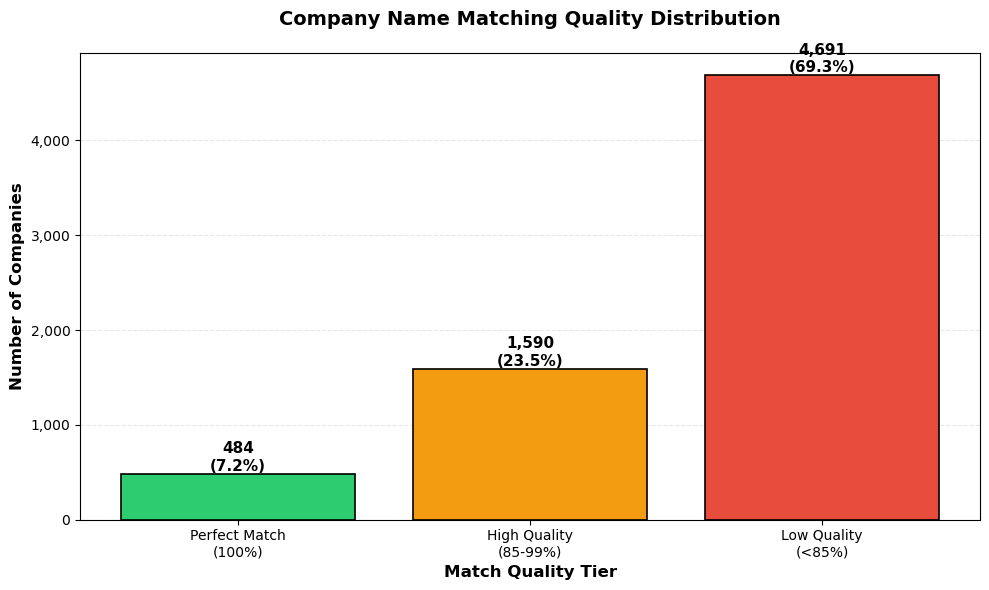


Total companies processed: 6,765


In [ ]:
# Create column chart for match quality distribution
import matplotlib.pyplot as plt

# Prepare data
categories = ['Perfect Match\n(100%)', 'High Quality\n(85-99%)', 'Low Quality\n(<85%)']
counts = [len(perfect_match_df), len(high_quality_df), len(low_quality_df)]
percentages = [
    (len(perfect_match_df) / len(adhoc_leads)) * 100,
    (len(high_quality_df) / len(adhoc_leads)) * 100,
    (len(low_quality_df) / len(adhoc_leads)) * 100
]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars with custom colors
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize chart
ax.set_ylabel('Number of Companies', fontsize=12, fontweight='bold')
ax.set_xlabel('Match Quality Tier', fontsize=12, fontweight='bold')
ax.set_title('Company Name Matching Quality Distribution', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print(f"\nTotal companies processed: {len(adhoc_leads):,}")

In [ ]:
import pandas as pd

# --- Combine DataFrames ---
combined_df = pd.concat(
    [
        perfect_match_df.assign(MATCH_QUALITY="Perfect Match (100%)"),
        high_quality_df.assign(MATCH_QUALITY="High Quality (85–99%)")
    ],
    ignore_index=True
)

# --- Output file path ---
output_file = r"C:\Users\teele\Documents\GitHub\Adhoc_Leads_Refinement_Pipeline\10k_adhoc_leads\Merged_Raw_Data\Le Peng_Perfect_and_High_Quality_Matches.xlsx"

# --- Export to Excel ---
combined_df.to_excel(output_file, index=False)

print(f"Excel file created successfully.")
print(f"Total records exported: {len(combined_df):,}")


### Download output as Excel files

In [ ]:
# import pandas as pd

# # Path where you want to save the Excel file
# output_path = r"C:\Users\teele\Documents\GitHub\Adhoc_Leads_Refinement_Pipeline\10k_adhoc_leads\Merged_Raw_Data\Merge_Kalai_and_Ish\perfect_match_output.xlsx"

# # Save only the selected columns (optional)
# perfect_match_df[
# ["COMPANY_NAME", 
# "ENTITY_NAME", 
# "SIMILARITY_SCORE", 
# "UEN", 
# "PIC_NAME", 
# "DESIGNATION", 
# "CONTACT_NUMBER_1_FORMATTED", 
# "CONTACT_NUMBER_2_FORMATTED",
# "CONTACT_NUMBER_3_FORMATTED",
# "CONTACT_NUMBER_4_FORMATTED",
# "CONTACT_NUMBER_5_FORMATTED",
# "CONTACT_NUMBER_6_FORMATTED",
# "CONTACT_NUMBER_7_FORMATTED",
# "ADDRESS",
# "EMAIL_1",
# "EMAIL_2",
# "EMAIL_3",
# "EMAIL_4",
# "EMAIL_5",
# "EMAIL_6",
# "EMAIL_7"
# ]
# ].to_excel(
#     output_path,
#     index=False
# )

# print("File saved successfully:", output_path)


File saved successfully: C:\Users\teele\Documents\GitHub\Adhoc_Leads_Refinement_Pipeline\10k_adhoc_leads\Merged_Raw_Data\Merge_Kalai_and_Ish\perfect_match_output.xlsx


In [ ]:
# list(perfect_match_df.columns)


['COMPANY_NAME',
 'PIC_NAME',
 'DESIGNATION',
 'CONTACT_NUMBER_1',
 'CONTACT_NUMBER_2',
 'CONTACT_NUMBER_3',
 'CONTACT_NUMBER_4',
 'CONTACT_NUMBER_5',
 'CONTACT_NUMBER_6',
 'CONTACT_NUMBER_7',
 'ADDRESS',
 'EMAIL_1',
 'EMAIL_2',
 'EMAIL_3',
 'EMAIL_4',
 'EMAIL_5',
 'EMAIL_6',
 'EMAIL_7',
 'CONTACT_NUMBER_1_CLEAN',
 'CONTACT_NUMBER_1_COUNTRY',
 'CONTACT_NUMBER_1_FORMATTED',
 'CONTACT_NUMBER_2_CLEAN',
 'CONTACT_NUMBER_2_COUNTRY',
 'CONTACT_NUMBER_2_FORMATTED',
 'CONTACT_NUMBER_3_CLEAN',
 'CONTACT_NUMBER_3_COUNTRY',
 'CONTACT_NUMBER_3_FORMATTED',
 'CONTACT_NUMBER_4_CLEAN',
 'CONTACT_NUMBER_4_COUNTRY',
 'CONTACT_NUMBER_4_FORMATTED',
 'CONTACT_NUMBER_5_CLEAN',
 'CONTACT_NUMBER_5_COUNTRY',
 'CONTACT_NUMBER_5_FORMATTED',
 'CONTACT_NUMBER_6_CLEAN',
 'CONTACT_NUMBER_6_COUNTRY',
 'CONTACT_NUMBER_6_FORMATTED',
 'CONTACT_NUMBER_7_CLEAN',
 'CONTACT_NUMBER_7_COUNTRY',
 'CONTACT_NUMBER_7_FORMATTED',
 'ENTITY_NAME',
 'UEN',
 'SIMILARITY_SCORE']

In [ ]:
https://recordowl.com/search?name={name of the business}

SyntaxError: invalid syntax (2390193072.py, line 1)

In [ ]:
low_quality_df